In [28]:
import pickle 
import logging
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

import tigramite.data_processing as td
import tigramite.plotting as tp
from tigramite.causal_effects import CausalEffects
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.parcorr_wls import ParCorrWLS

In [29]:
logging.basicConfig(
    level=logging.INFO,              
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    stream=sys.stdout
)
logger = logging.getLogger(__name__)
logging.getLogger("graph_validation_CI").setLevel(logging.CRITICAL)


In [30]:
def load_ts_df(
    file_path: Path, 
) -> pd.DataFrame:
    """Load q/climate ts df from LamaH-CE, and change index to datetime."""

    df = pd.read_csv(filepath_or_buffer=file_path, header=0, sep=";")

    df_date_index = (df
    .assign(date=pd.to_datetime(df.rename(columns={"DD": "day", "MM": "month", "YYYY": "year"})[["year", "month", "day"]]))
    .drop(columns=["DD", "MM", "YYYY"])
    .set_index("date")
    )
    return df_date_index

def calculate_snowmelt(
        climate_ts_df: pd.DataFrame
) -> pd.DataFrame: 
    """Calculate snowmelt as depletion of SWE from t-1 to t in basin."""

    snow_ts = climate_ts_df.swe

    # First day cannot have depletion.
    snow_depletion = [np.nan]
    prev = snow_ts.iloc[0]

    for day in range(1, len(snow_ts)):

        current = snow_ts.iloc[day]

        # Calculate delta swe from t-1 to t, if positive denote, else 0.
        depletion = prev - current

        if depletion > 0: 

            snow_depletion.append(depletion)

        else: 

            snow_depletion.append(0)

        prev = current

    # Sanity check. 
    logger.info(
        "Calculated snowmelt:"
        f"\n min  : {np.nanmin(snow_depletion)}"
        f"\n max  : {np.nanmax(snow_depletion)}"
        f"\n mean : {np.nanmean(snow_depletion)}"
    )

    # Add to df.
    climate_ts_df["snowmelt"] = snow_depletion

    return climate_ts_df


def construct_vars_tg(
        lamah_ce_path: Path, 
        basin_id: int
) -> pd.DataFrame: 

    # Load df's. 
    climate_ts_path = lamah_ce_path / f"B_basins_intermediate_all/2_timeseries/daily/ID_{basin_id}.csv"
    q_ts_path = lamah_ce_path / f"D_gauges/2_timeseries/daily/ID_{basin_id}.csv"

    climate_ts_df = load_ts_df(climate_ts_path) 
    q_ts_df = load_ts_df(q_ts_path) 
    logger.info(f"Loaded data from:\n{climate_ts_path}\n{q_ts_path}")

    climate_ts_df = calculate_snowmelt(climate_ts_df=climate_ts_df)

    # Select only relvant climate vars.
    climate_vars_df = climate_ts_df.loc[:, ["surf_net_solar_rad_mean", "2m_temp_mean", "prec", "total_et", "volsw_123", "snowmelt"]]

    # Add discharge
    vars_df = pd.concat([climate_vars_df, q_ts_df["qobs"]], axis=1)

    # Rename for easier access.
    vars_df.columns = ["RAD", "TEMP", "P", "ET", "SM", "SNO", "Q"]

    # Remove missing.
    vars_df = vars_df.dropna()

    if vars_df.isna().any(axis=None): 
        logger.error("vars_df still conains NA.")
        raise


    # Convert to tigramite form. 
    vars_tg = td.DataFrame(data=vars_df.to_numpy(), var_names=vars_df.columns)

    logger.info(f"Variable names in vars_tg: {vars_tg.var_names}")

    return vars_tg, vars_df


# Plot utils 
def add_rev_contemp_links(
        graph: np.ndarray
) -> np.ndarray: 

    n_vars = graph.shape[0]

    for i in range(n_vars): 

        for j in range(n_vars): 

            # Check if i has contemp link to j [i, j, 0], and if so add reverse. 
         
            if graph[i,j,0] == "-->":

                graph[j,i,0] = "<--"

    return graph

def add_self_causation(
        graph: np.ndarray
) -> np.ndarray: 
    
    n_vars = graph.shape[0]

    for i in range(n_vars): 

        # Add timelag 1 arrow.
        graph[i, i, 1] = "-->"

    return graph


## Data

In [31]:
#lamah_ce_path = Path("/home/tripleuuu/Nextcloud/coding/causal_inference/snow_causal_inference/data/raw_data/2_LamaH-CE_daily")
lamah_ce_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily")

basin_id = 802

experiment_dir = Path("../experiments") / f"{basin_id}"
experiment_dir.mkdir(exist_ok=True)

climate_ts_802_path = lamah_ce_path / f"B_basins_intermediate_all/2_timeseries/daily/ID_{basin_id}.csv"
q_ts_802_path = lamah_ce_path / f"D_gauges/2_timeseries/daily/ID_{basin_id}.csv"
catchment_attributes_path = lamah_ce_path / f"B_basins_intermediate_all/1_attributes/Catchment_attributes.csv"

### EDA


In [32]:
climate_ts_802_df = load_ts_df(climate_ts_802_path) 
q_ts_802_df = load_ts_df(q_ts_802_path) 
catchment_attributes_df = pd.read_csv(catchment_attributes_path, header=0, sep=";")
catchment_attributes_df.set_index("ID", inplace=True)

In [ ]:
catchment_attributes_df.loc[802, ["area_calc", "elev_mean", "frac_snow", "p_mean"]]

area_calc     140.977
elev_mean    2179.000
frac_snow       0.470
p_mean          3.970
Name: 802, dtype: float64

In [56]:
catchment_attributes_df.loc[:, ["area_calc", "elev_mean", "frac_snow", "p_mean"]].describe()

,area_calc,elev_mean,frac_snow,p_mean
count,859.000000,859.000000,859.000000,859.000000
mean,196.553271,935.362049,0.174831,3.400489
std,262.924854,586.241106,0.122252,0.999311
min,1.316000,143.000000,0.040000,1.730000
25%,58.233500,498.000000,0.080000,2.615000
50%,113.794000,719.000000,0.120000,3.250000
75%,217.764000,1244.000000,0.250000,4.210000
max,2500.384000,3122.000000,0.610000,5.710000


### CEE Prep

In [34]:
vars_tg, vars_df = construct_vars_tg(lamah_ce_path=lamah_ce_path, basin_id=802)

2026-09-23 12:08:04 - INFO - Loaded data from:
/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries/daily/ID_802.csv
/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/2_timeseries/daily/ID_802.csv
2026-09-23 12:08:04 - INFO - Calculated snowmelt:
 min  : 0.0
 max  : 32.19999999999999
 mean : 1.9031755950291371
2026-09-23 12:08:04 - INFO - Variable names in vars_tg: Index(['RAD', 'TEMP', 'P', 'ET', 'SM', 'SNO', 'Q'], dtype='str')


(<Figure size 2000x1000 with 7 Axes>,
 array([<Axes: ylabel='RAD'>, <Axes: ylabel='TEMP'>, <Axes: ylabel='P'>,
        <Axes: ylabel='ET'>, <Axes: ylabel='SM'>, <Axes: ylabel='SNO'>,
        <Axes: ylabel='Q'>], dtype=object))

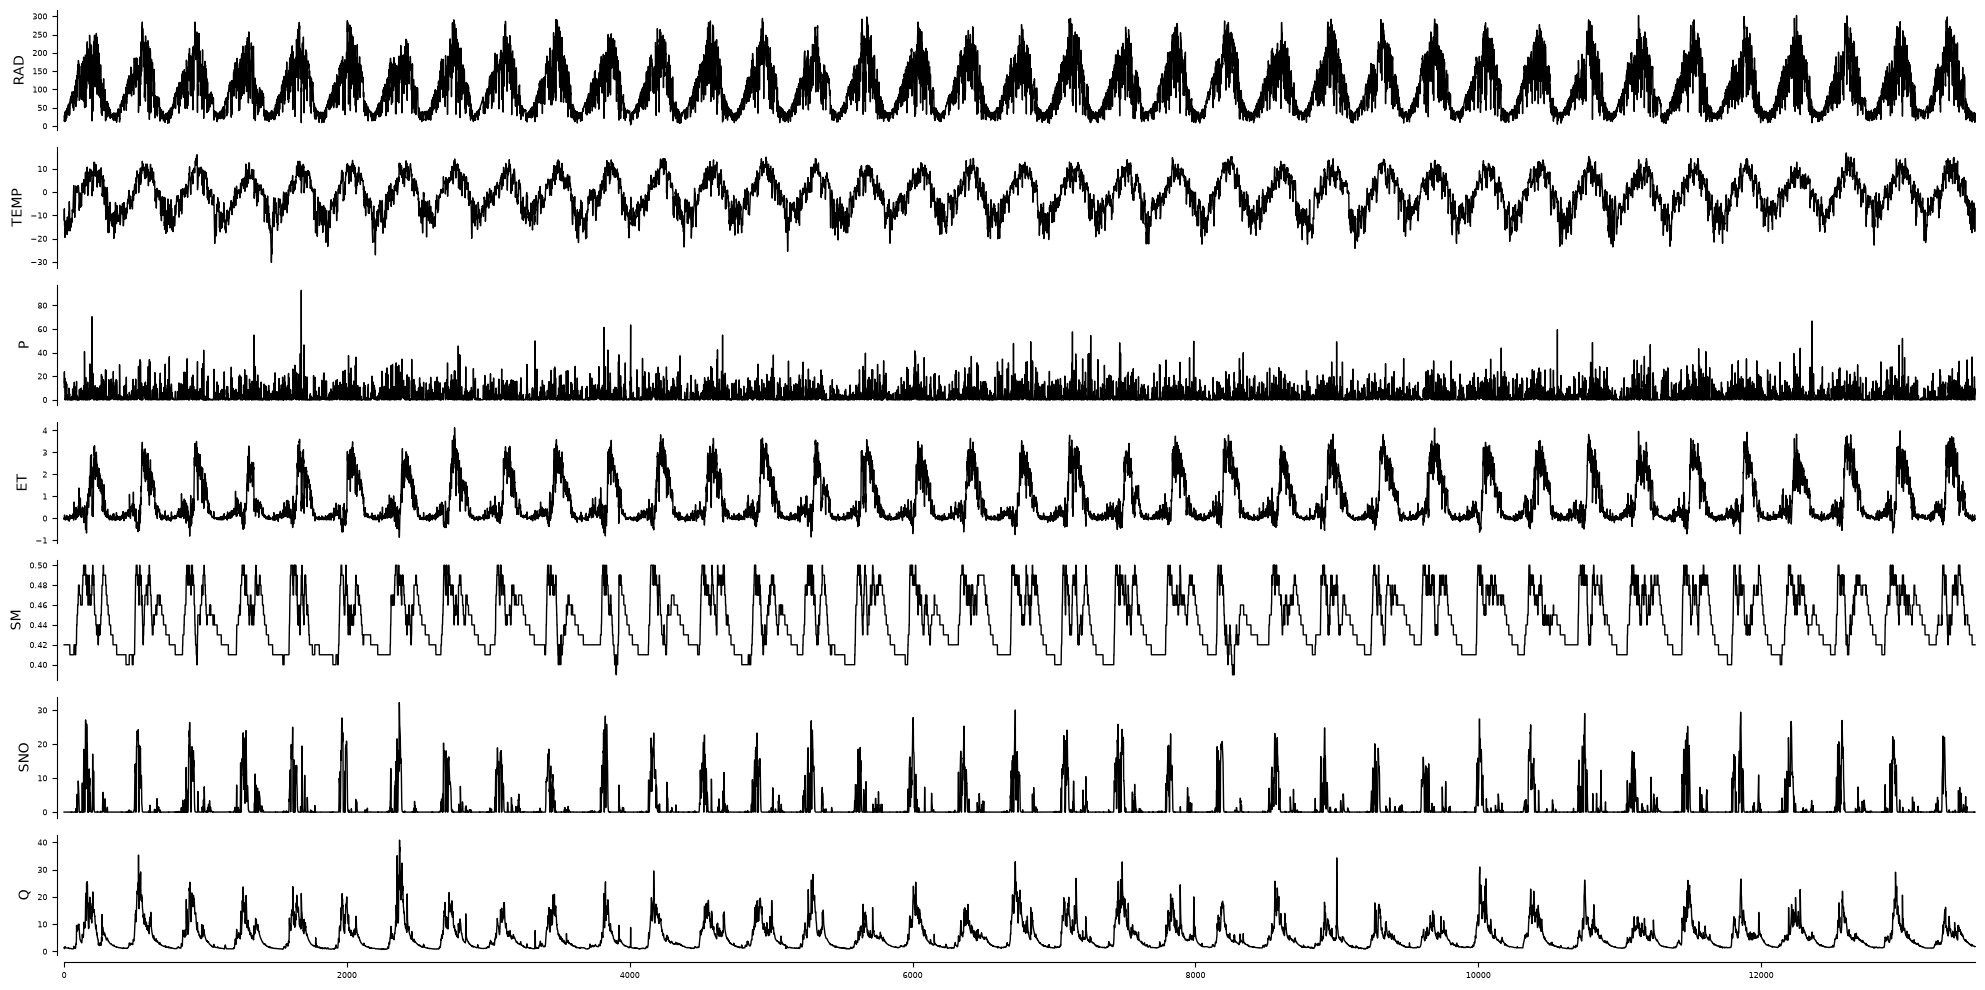

In [35]:
tp.plot_timeseries(dataframe=vars_tg, figsize=(20,10))

Check for seasons with no snowmelt.

In [36]:
fig = go.Figure(data=go.Scatter(
    x=vars_df.index,
    y=vars_df.TEMP,
    mode='lines'
))

fig.add_scatter(x=vars_df.index, y=vars_df.RAD, mode="lines")

fig.update_layout(title="Snowmelt 1981-2017")
fig.show()

In [37]:
var_names_with_id = []

for i, var_name in enumerate(vars_df.columns): 

    var_names_with_id.append(f"{i} {var_name}")

## 1. Graph-Validation 

Check that the distribution is markov to the graph. 

### First draft of graph

(<Figure size 640x480 with 1 Axes>, <Axes: >)

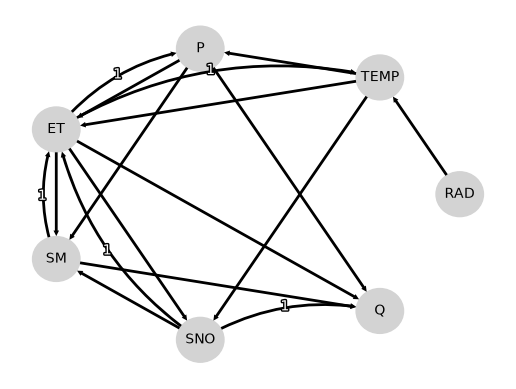

In [38]:
# define tigramite graph and plot it 
draft = 1

N = len(vars_df.columns)
tau_max = 3  

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# RAD 
graph[0, 1, 0] = "-->" # RAD drives Temp

# T
graph[1, 2, 0] = "-->" # impacts advection, therefore P
graph[1, 3, 0] = "-->" # controls ET, in terms of energy
graph[1, 5, 0] = "-->" # controls SNO

# P 
graph[2, 3, 0] = "-->" # limits ET, in terms of availalbe water
graph[2, 4, 0] = "-->" # water source for SM 
graph[2, 6, 0] = "-->" # contributes to Q

# ET
graph[3, 1, 1] = "-->" # condensation cools, lagged to avoid cycle
graph[3, 2, 1] = "-->" # condensation drives P 
graph[3, 4, 0] = "-->" # drains SM
graph[3, 5, 0] = "-->" # limits snowmelt by consuming energy to evaporate snow
graph[3, 6, 0] = "-->" # other outflux next to Q 

# SM 
graph[4, 3, 1] = "-->" # after a day of a prec, water from Soil can evaporate
graph[4, 6, 0] = "-->" # water in soil doesnt runoff, if soil saturated more surface discharge

# SNO
graph[5, 3, 1] = "-->" # supplies available water to evaporate 
graph[5, 4, 0] = "-->" # melt infiltrates
graph[5, 6, 1] = "-->" # melt contributes to Q

graph = add_self_causation(graph=graph)

graph = add_rev_contemp_links(graph=graph)

tp.plot_graph(
    graph=graph,
    var_names=vars_df.columns,
    arrow_linewidth=2,
)

(<Figure size 1000x500 with 1 Axes>, <Axes: >)

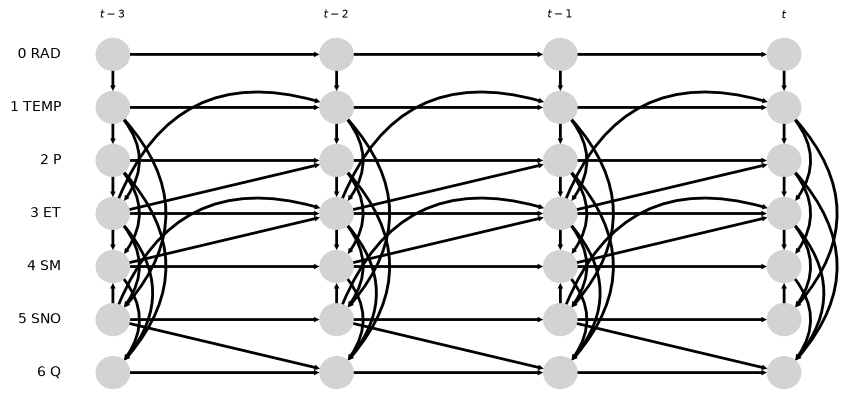

In [39]:
tp.plot_time_series_graph(graph=graph, var_names=var_names_with_id, curved_radius=0.5, arrow_linewidth=2, figsize=(10, 5))

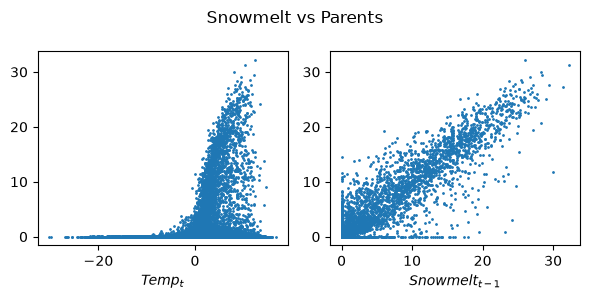

In [40]:
# Plot snow vs parents
fig, axs = plt.subplots(1, 2, figsize=(6,3))

size = 1

axs[0].scatter(x=vars_df.TEMP, y=vars_df.SNO, s=size)
axs[0].set_xlabel("$Temp_t$")
axs[1].scatter(x=vars_df.SNO[:-1], y=vars_df.SNO[1:], s=size)
axs[1].set_xlabel("$Snowmelt_{t-1}$")

fig.suptitle("Snowmelt vs Parents")
#fig.supylabel("$Snowmelt_t$", rotation=0)
plt.tight_layout()

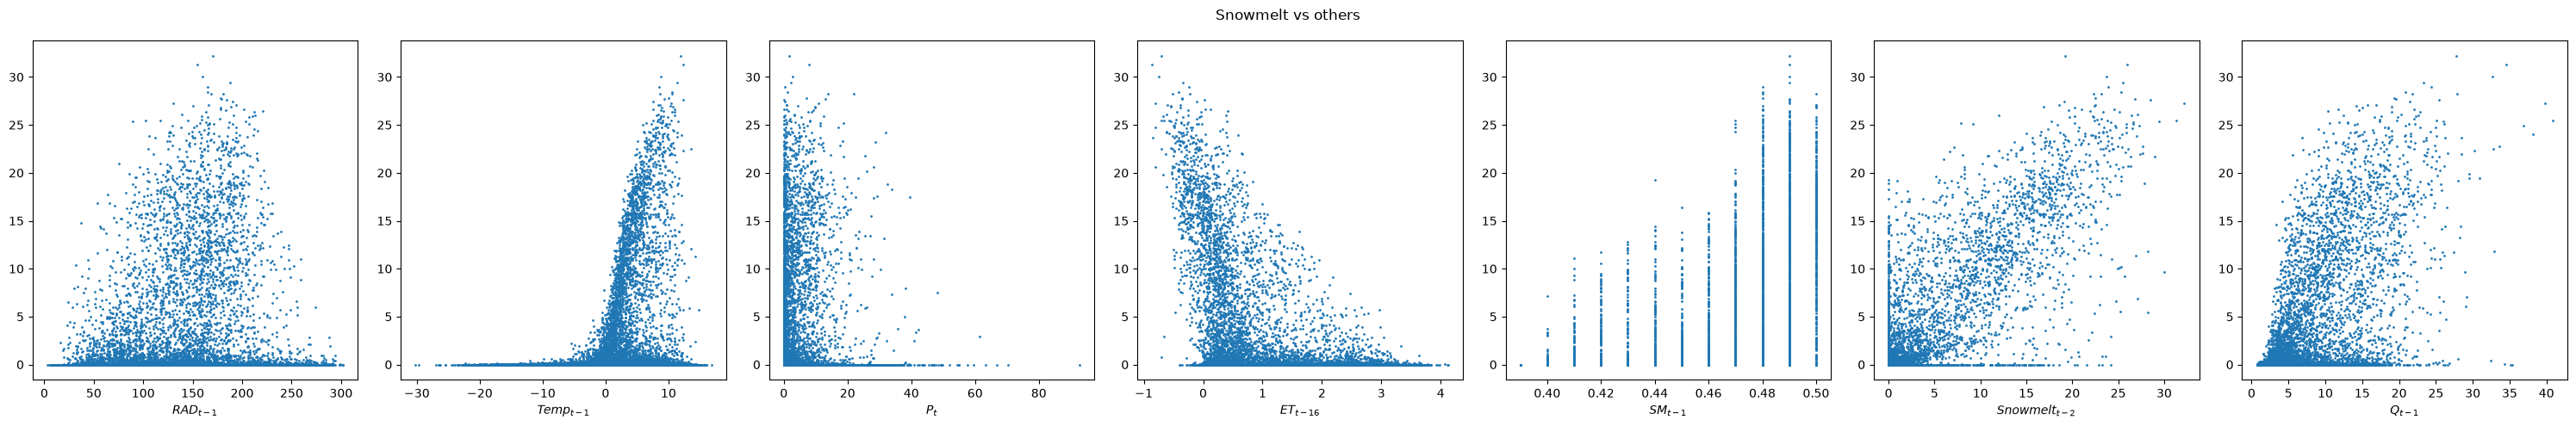

In [41]:
# Plot snow vs others 

fig, axs = plt.subplots(1, 7, figsize=(30,5))

axs[0].scatter(x=vars_df.RAD[:-1], y=vars_df.SNO[1:], s=size)
axs[0].set_xlabel("$RAD_{t-1}$")
axs[1].scatter(x=vars_df.TEMP[:-1], y=vars_df.SNO[1:], s=size)
axs[1].set_xlabel("$Temp_{t-1}$")
axs[2].scatter(x=vars_df.P, y=vars_df.SNO, s=size)
axs[2].set_xlabel("$P_t$")
axs[3].scatter(x=vars_df.ET[:-1], y=vars_df.SNO[1:], s=size)
axs[3].set_xlabel("$ET_{t-16}$")
axs[4].scatter(x=vars_df.SM[:-1], y=vars_df.SNO[1:], s=size)
axs[4].set_xlabel("$SM_{t-1}$")
axs[5].scatter(x=vars_df.SNO[:-2], y=vars_df.SNO[2:], s=size)
axs[5].set_xlabel("$Snowmelt_{t-2}$")
axs[6].scatter(x=vars_df.Q[:-1], y=vars_df.SNO[1:], s=size)
axs[6].set_xlabel("$Q_{t-1}$")


fig.suptitle("Snowmelt vs others")
#fig.supylabel("$Snowmelt_t$")
plt.tight_layout()

##### Formulate dict with configuration for CI tests. 

In [42]:
CI_config_dict = {

    "use_Pa_X": True, 

    "val_d": False,

    (5,0) : {
        "X_dict": {
            (0, 0)  : [(0, -1)],
            (1, -1) : [(0, -1), (1, -2), (3, -2)],
            (2, 0)  : [(1, 0), (2, -1), (3, -1)],
            (3, -1) : [(1, -1), (2, -1), (3, -2), (4, -2), (5, -2)],
            (4, -1) : [(2, -1), (3, -1), (4, -2), (5, -1)],
            (5, -2) : [(1, -2), (3, -2), (5, -3)],
            (6, -1) : [(2, -1), (3, -1), (4, -1), (5, -2), (6, -2)]
        },                   
        "Y_parents": [(1, 0), (3, 0), (5, -1)]
    },

    "graph": graph
    
}

draft_dir = experiment_dir / f"draft_{draft}"
draft_dir.mkdir(exist_ok=True)

with open(draft_dir / "CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

##### Run tests on node and inspect results.

In [43]:
draft_result_paths = list(draft_dir.glob("*results*"))
draft_results = {}

for path in draft_result_paths: 

    with open(path, "rb") as f: 
        draft_results[path.name] = pickle.load(f)
        
draft_results


{'CI_results_dict_22-09-2026_11:54:45.pkl': {(5,
   0): {'X_dict': {(0,
     0): [(np.float64(0.025172451433928433), 0.001996007984031936, True)],
    (1, -1): [(0, -1),
     (1, -2),
     (3, -2),
     (np.float64(0.02043509473004601), 0.001996007984031936, True)],
    (2, 0): [(1, 0),
     (2, -1),
     (3, -1),
     (np.float64(0.06640717111560157), 0.001996007984031936, True)],
    (3, -1): [(1, -1),
     (2, -1),
     (3, -2),
     (4, -2),
     (5, -2),
     (np.float64(0.007426620124791672), 0.001996007984031936, True)],
    (4, -1): [(2, -1),
     (3, -1),
     (4, -2),
     (5, -1),
     (np.float64(0.00395817476460536), 0.001996007984031936, True)],
    (5, -2): [(1, -2),
     (3, -2),
     (5, -3),
     (np.float64(-0.0009862820404267225), 0.09780439121756487, False)],
    (6, -1): [(2, -1),
     (3, -1),
     (4, -1),
     (5, -2),
     (6, -2),
     (np.float64(0.005165286158470117),
      0.001996007984031936,
      True)]}, 'Y_parents': [(1, 0), (3, 0), (5, -1)]},
  'gra

### Second Draft

(<Figure size 640x480 with 1 Axes>, <Axes: >)

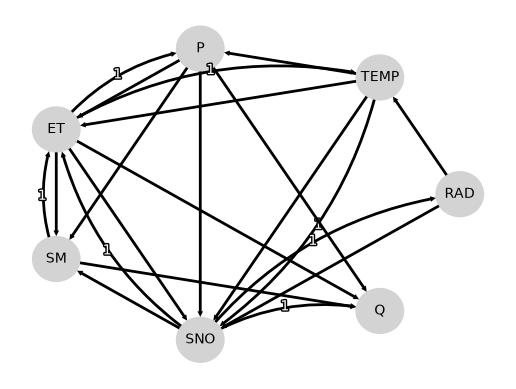

In [44]:
# define tigramite graph and plot it 
draft = 2

N = len(vars_df.columns)
tau_max = 3  

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# RAD 
graph[0, 1, 0] = "-->" # RAD drives Temp
graph[0, 5, 0] = "-->" # NEW: RAD drives SNO, as energy flux

# T
graph[1, 2, 0] = "-->" # impacts advection, therefore P
graph[1, 3, 0] = "-->" # controls ET, in terms of energy
graph[1, 5, 0] = "-->" # controls SNO
graph[1, 5, 1] = "-->" # NEW: also lagged via heat storage in soil

# P 
graph[2, 3, 0] = "-->" # limits ET, in terms of availalbe water
graph[2, 4, 0] = "-->" # water source for SM 
graph[2, 5, 0] = "-->" # NEW: ROS 
graph[2, 6, 0] = "-->" # contributes to Q

# ET
graph[3, 1, 1] = "-->" # condensation cools, lagged to avoid cycle
graph[3, 2, 1] = "-->" # condensation drives P 
graph[3, 4, 0] = "-->" # drains SM
graph[3, 5, 0] = "-->" # limits snowmelt by consuming energy to evaporate snow
graph[3, 6, 0] = "-->" # other outflux next to Q 

# SM 
graph[4, 3, 1] = "-->" # after a day of a prec, water from Soil can evaporate
graph[4, 6, 0] = "-->" # water in soil doesnt runoff, if soil saturated more surface discharge

# SNO
graph[5, 0, 1] = "-->" # NEW: drives incoming RAD via albedo decrease
graph[5, 3, 1] = "-->" # supplies available water to evaporate 
graph[5, 4, 0] = "-->" # melt infiltrates
graph[5, 6, 1] = "-->" # melt contributes to Q

graph = add_self_causation(graph=graph)

graph = add_rev_contemp_links(graph=graph)

tp.plot_graph(
    graph=graph,
    var_names=vars_df.columns,
    arrow_linewidth=2,
)

(<Figure size 1000x500 with 1 Axes>, <Axes: >)

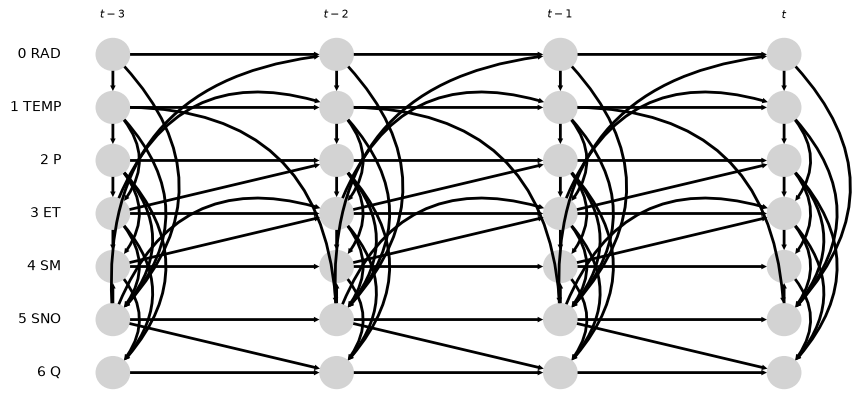

In [45]:
tp.plot_time_series_graph(graph=graph, var_names=var_names_with_id, curved_radius=0.5, arrow_linewidth=2, figsize=(10, 5))

##### Formulate dict with configuration for CI tests. 

In [46]:
CI_config_dict = {

    "use_Pa_X": True, 

    "val_d": False,

    (5,0) : {
        "X_dict": {
            (0, -1) : [(0, -2), (5, -2)],
            (1, -2) : [(0, -2), (1, -3), (3, -3)],
            (2, -1) : [(1, -1), (2, -2), (3, -2)],
            (3, -1) : [(1, -1), (2, -1), (3, -2), (4, -2), (5, -2)],
            (4, -1) : [(2, -1), (3, -1), (4, -2), (5, -1)],
            (5, -2) : [(0, -2), (1, -2), (3, -2), (5, -3)],
            (6, -1) : [(2, -1), (3, -1), (4, -1), (5, -2), (6, -2)] # unchanged
        },                   
        "Y_parents": [(0, 0), (1, 0), (1, -1), (2, 0), (3, 0), (5, -1)]
    },

    "graph": graph
    
}

draft_dir = experiment_dir / f"draft_{draft}"
draft_dir.mkdir(exist_ok=True)

with open(draft_dir / "CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

##### Run tests on node and inspect results.

In [47]:
draft_result_paths = list(draft_dir.glob("*results*"))
draft_results = {}

for path in draft_result_paths: 

    with open(path, "rb") as f: 
        draft_results[path.name] = pickle.load(f)
        
draft_results


{'CI_results_dict_22-09-2026_13:45:33.pkl': {'use_Pa_X': True,
  'val_d': True,
  (5,
   0): {'X_dict': {(0, -1): [(0, -2),
     (5, -2),
     (np.float64(0.006256379514577581), 0.001996007984031936, True)],
    (1, -2): [(0, -2),
     (1, -3),
     (3, -3),
     (np.float64(0.0022508246232675333), 0.001996007984031936, True)],
    (2, -1): [(1, -1),
     (2, -2),
     (3, -2),
     (np.float64(0.017176481234333796), 0.001996007984031936, True)],
    (3, -1): [(1, -1),
     (2, -1),
     (3, -2),
     (4, -2),
     (5, -2),
     (np.float64(0.0037907138095043535), 0.001996007984031936, True)],
    (4, -1): [(2, -1),
     (3, -1),
     (4, -2),
     (5, -1),
     (np.float64(0.0017570665871384783), 0.013972055888223553, False)],
    (5, -2): [(0, -2),
     (1, -2),
     (3, -2),
     (5, -3),
     (np.float64(-0.0021131498155422257), 0.936127744510978, False)],
    (6, -1): [(2, -1),
     (3, -1),
     (4, -1),
     (5, -2),
     (6, -2),
     (np.float64(0.0012992221106404855),
      0

### Third Draft

(<Figure size 640x480 with 1 Axes>, <Axes: >)

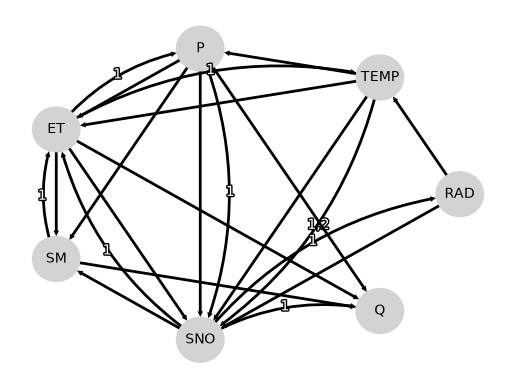

In [54]:
# define tigramite graph and plot it 
draft = 3

N = len(vars_df.columns)
tau_max = 4  

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# RAD 
graph[0, 1, 0] = "-->" # RAD drives Temp
graph[0, 5, 0] = "-->" # RAD drives SNO, as energy flux

# T
graph[1, 2, 0] = "-->" # impacts advection, therefore P
graph[1, 3, 0] = "-->" # controls ET, in terms of energy
graph[1, 5, 0] = "-->" # controls SNO
graph[1, 5, 1] = "-->" # lso lagged via heat storage in soil
graph[1, 5, 2] = "-->" # NEW: also 2 lagged via heat storage in soil

# P 
graph[2, 3, 0] = "-->" # limits ET, in terms of availalbe water
graph[2, 4, 0] = "-->" # water source for SM 
graph[2, 5, 0] = "-->" # ROS 
graph[2, 5, 1] = "-->" # NEW water in snow persists for some time (up to seven days)
graph[2, 6, 0] = "-->" # contributes to Q

# ET
graph[3, 1, 1] = "-->" # condensation cools, lagged to avoid cycle
graph[3, 2, 1] = "-->" # condensation drives P 
graph[3, 4, 0] = "-->" # drains SM
graph[3, 5, 0] = "-->" # limits snowmelt by consuming energy to evaporate snow
graph[3, 6, 0] = "-->" # other outflux next to Q 

# SM 
graph[4, 3, 1] = "-->" # after a day of a prec, water from Soil can evaporate
graph[4, 6, 0] = "-->" # water in soil doesnt runoff, if soil saturated more surface discharge

# SNO
graph[5, 0, 1] = "-->" # NEW: drives incoming RAD via albedo decrease
graph[5, 3, 1] = "-->" # supplies available water to evaporate 
graph[5, 4, 0] = "-->" # melt infiltrates
graph[5, 6, 1] = "-->" # melt contributes to Q

graph = add_self_causation(graph=graph)

graph = add_rev_contemp_links(graph=graph)

tp.plot_graph(
    graph=graph,
    var_names=vars_df.columns,
    arrow_linewidth=2,
)

(<Figure size 1000x500 with 1 Axes>, <Axes: >)

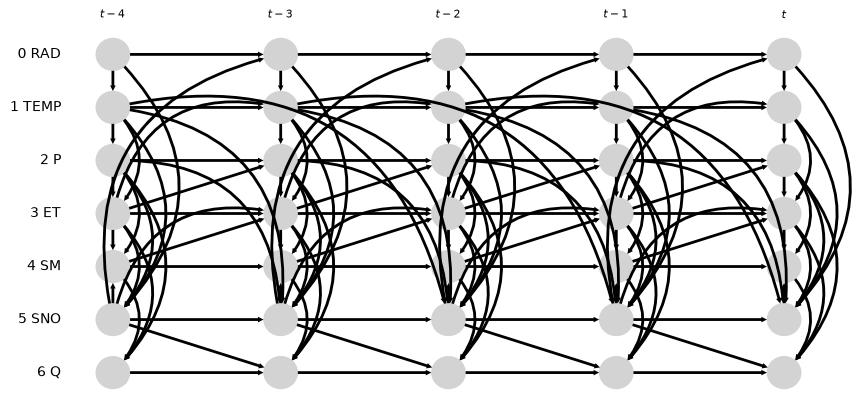

In [55]:
tp.plot_time_series_graph(graph=graph, var_names=var_names_with_id, curved_radius=0.5, arrow_linewidth=2, figsize=(10, 5))

##### Formulate dict with configuration for CI tests. 

In [50]:
CI_config_dict = {

    "use_Pa_X": True, 

    "val_d": False,

    (5,0) : {
        "X_dict": {
            (0, -1) : [(0, -2), (5, -2)], # unchanged 
            (1, -3) : [(0, -3), (1, -4), (3, -4)],
            (2, -2) : [(1, -2), (2, -3), (3, -3)],
            (3, -1) : [(1, -1), (2, -1), (3, -2), (4, -2), (5, -2)], # unchanged
            (4, -1) : [(2, -1), (3, -1), (4, -2), (5, -1)], # unchanged
            (5, -2) : [(0, -2), (1, -2), (3, -2), (5, -3)], # unchanged
            (6, -1) : [(2, -1), (3, -1), (4, -1), (5, -2), (6, -2)] # unchanged
        },                   
        "Y_parents": [(0, 0), (1, 0), (1, -1), (1, -2), (2, 0), (2, -1), (3, 0), (5, -1)]
    },

    "graph": graph
    
}

draft_dir = experiment_dir / f"draft_{draft}"
draft_dir.mkdir(exist_ok=True)

with open(draft_dir / "CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

##### Run tests on node and inspect results.

In [57]:
draft_result_paths = list(draft_dir.glob("*results*"))
draft_results = {}

for path in draft_result_paths: 

    with open(path, "rb") as f: 
        draft_results[path.name] = pickle.load(f)
        
draft_results


{'CI_results_dict_23-09-2026_12:09:07.pkl': {'use_Pa_X': True,
  'val_d': False,
  (5,
   0): {'X_dict': {(0, -1): [(0, -2),
     (5, -2),
     (np.float64(0.002329239722404175), 0.003992015968063872, True)],
    (1, -3): [(0, -3),
     (1, -4),
     (3, -4),
     (np.float64(0.0012714896850742896), 0.2714570858283433, False)],
    (2, -2): [(1, -2),
     (2, -3),
     (3, -3),
     (np.float64(0.004496284694381014), 0.001996007984031936, True)],
    (3, -1): [(1, -1),
     (2, -1),
     (3, -2),
     (4, -2),
     (5, -2),
     (np.float64(0.003478060949052786), 0.001996007984031936, True)],
    (4, -1): [(2, -1),
     (3, -1),
     (4, -2),
     (5, -1),
     (np.float64(0.0017864987650288988), 0.007984031936127744, True)],
    (5, -2): [(0, -2),
     (1, -2),
     (3, -2),
     (5, -3),
     (np.float64(-0.0014287700761155264), 0.9301397205588823, False)],
    (6, -1): [(2, -1),
     (3, -1),
     (4, -1),
     (5, -2),
     (6, -2),
     (np.float64(0.0012609066007120973),
      0.

### Fourth Draft

(<Figure size 640x480 with 1 Axes>, <Axes: >)

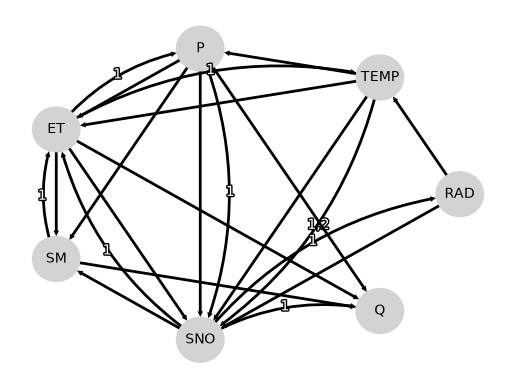

In [ ]:
# define tigramite graph and plot it 
draft = 4

N = len(vars_df.columns)
tau_max = 4  

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# RAD 
graph[0, 1, 0] = "-->" # RAD drives Temp
graph[0, 5, 0] = "-->" # RAD drives SNO, as energy flux

# T
graph[1, 2, 0] = "-->" # impacts advection, therefore P
graph[1, 3, 0] = "-->" # controls ET, in terms of energy
graph[1, 5, 0] = "-->" # controls SNO
graph[1, 5, 1] = "-->" # lso lagged via heat storage in soil
graph[1, 5, 2] = "-->" # also 2 lagged via heat storage in soil

# P 
graph[2, 3, 0] = "-->" # limits ET, in terms of availalbe water
graph[2, 4, 0] = "-->" # water source for SM 
graph[2, 5, 0] = "-->" # ROS 
graph[2, 5, 1] = "-->" # water in snow persists for some time (up to seven days)
graph[2, 5, 2] = "-->" # NEW: up to seven days
graph[2, 6, 0] = "-->" # contributes to Q

# ET
graph[3, 1, 1] = "-->" # condensation cools, lagged to avoid cycle
graph[3, 2, 1] = "-->" # condensation drives P 
graph[3, 4, 0] = "-->" # drains SM
graph[3, 5, 0] = "-->" # limits snowmelt by consuming energy to evaporate snow
graph[3, 6, 0] = "-->" # other outflux next to Q 

# SM 
graph[4, 3, 1] = "-->" # after a day of a prec, water from Soil can evaporate
graph[4, 6, 0] = "-->" # water in soil doesnt runoff, if soil saturated more surface discharge

# SNO
graph[5, 0, 1] = "-->" # : drives incoming RAD via albedo decrease
graph[5, 3, 1] = "-->" # supplies available water to evaporate 
graph[5, 4, 0] = "-->" # melt infiltrates
graph[5, 6, 1] = "-->" # melt contributes to Q

graph = add_self_causation(graph=graph)

graph = add_rev_contemp_links(graph=graph)

tp.plot_graph(
    graph=graph,
    var_names=vars_df.columns,
    arrow_linewidth=2,
)

(<Figure size 1000x500 with 1 Axes>, <Axes: >)

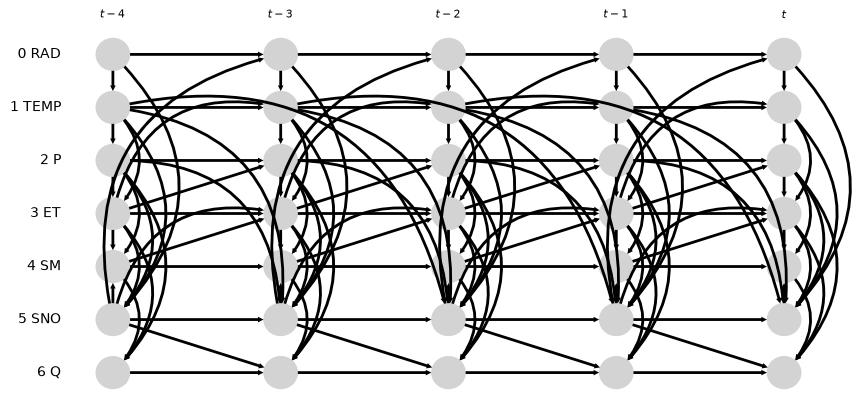

In [ ]:
tp.plot_time_series_graph(graph=graph, var_names=var_names_with_id, curved_radius=0.5, arrow_linewidth=2, figsize=(10, 5))

##### Formulate dict with configuration for CI tests. 

In [ ]:
CI_config_dict = {

    "use_Pa_X": True, 

    "val_d": False,

    (5,0) : {
        "X_dict": {
            (0, -1) : [(0, -2), (5, -2)], # unchanged 
            (1, -3) : [(0, -3), (1, -4), (3, -4)],
            (2, -2) : [(1, -2), (2, -3), (3, -3)],
            (3, -1) : [(1, -1), (2, -1), (3, -2), (4, -2), (5, -2)], # unchanged
            (4, -1) : [(2, -1), (3, -1), (4, -2), (5, -1)], # unchanged
            (5, -2) : [(0, -2), (1, -2), (3, -2), (5, -3)], # unchanged
            (6, -1) : [(2, -1), (3, -1), (4, -1), (5, -2), (6, -2)] # unchanged
        },                   
        "Y_parents": [(0, 0), (1, 0), (1, -1), (1, -2), (2, 0), (2, -1), (3, 0), (5, -1)]
    },

    "graph": graph
    
}

draft_dir = experiment_dir / f"draft_{draft}"
draft_dir.mkdir(exist_ok=True)

with open(draft_dir / "CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

##### Run tests on node and inspect results.

In [ ]:
draft_result_paths = list(draft_dir.glob("*results*"))
draft_results = {}

for path in draft_result_paths: 

    with open(path, "rb") as f: 
        draft_results[path.name] = pickle.load(f)
        
draft_results


{}

## 2. Causal Effect Estimation

In [52]:
X = [(4, -1)]
Y = [(5, 0)]
causal_effects = CausalEffects(graph=graph, graph_type="stationary_dag", X=X, Y=Y, check_SM_overlap=True, verbosity=1)


##
## Initializing CausalEffects class
##

Input:

graph_type = stationary_dag
X = [(4, -1)]
Y = [(5, 0)]
S = []
M = [(np.int64(3), np.int64(0))]





In [53]:
causal_effects.fit_total_effect(
    dataframe=vars_tg,
    estimator=RandomForestRegressor(),
    adjustment_set=[(0,-1), (0, -2), (1, -1), (2, -2), (4, -2), (6,-1)]
)

ValueError: Chosen adjustment_set is not valid.

In [ ]:
intervention_data = 2*np.ones((1, 1))
y1 = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
        )
print("y1 = ",y1)

intervention_data = 13.*np.ones((1, 1))
y2 = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
        )
print("y2 = ",y2)

y1 =  [5.56271542]
y2 =  [6.17311014]


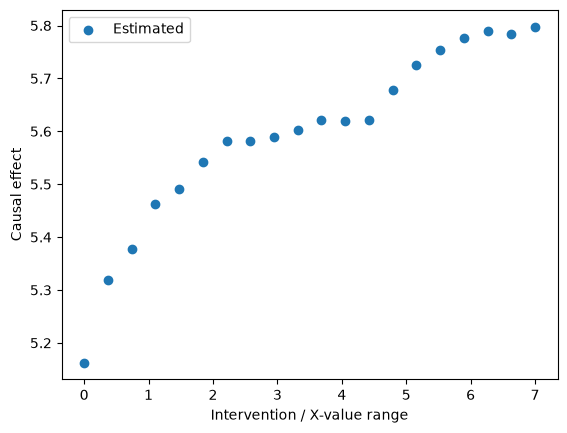

In [ ]:
intervention_data = np.linspace(0, 7, 20).reshape(20, 1)
estimated_causal_effects = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
        )
plt.scatter(intervention_data[:,0], estimated_causal_effects, label="Estimated")
plt.xlabel('Intervention / X-value range')
plt.ylabel('Causal effect')
plt.legend()
plt.show()